# Fraud Detection — Transaction Risk Scoring
### Detectron AI · Module 01

Real fraud-detection systems rarely rely on a single signal. This notebook builds
a synthetic transaction dataset, engineers risk features (amount deviation, time-of-day,
geography, velocity), and trains a **Random Forest classifier** to flag fraudulent
transactions — then compares it against the transparent rule-based scorer used in the
live web demo.


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

np.random.seed(42)


## 1. Generate a synthetic labeled transaction dataset

(In a real project this would be the Kaggle Credit Card Fraud Detection dataset.)

In [2]:
n_legit = 2000
n_fraud = 120

legit = pd.DataFrame({
    "amount": np.random.normal(2400, 1200, n_legit).clip(50, None),
    "hour": np.random.choice(range(7, 23), n_legit),
    "is_international": np.random.choice([0, 1], n_legit, p=[0.95, 0.05]),
    "is_new_merchant": np.random.choice([0, 1], n_legit, p=[0.85, 0.15]),
    "tx_count_last_hr": np.random.poisson(1.0, n_legit),
    "label": 0
})

fraud = pd.DataFrame({
    "amount": np.random.normal(18000, 9000, n_fraud).clip(500, None),
    "hour": np.random.choice(range(0, 24), n_fraud),
    "is_international": np.random.choice([0, 1], n_fraud, p=[0.4, 0.6]),
    "is_new_merchant": np.random.choice([0, 1], n_fraud, p=[0.25, 0.75]),
    "tx_count_last_hr": np.random.poisson(4.5, n_fraud),
    "label": 1
})

df = pd.concat([legit, fraud], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
df.describe()


,amount,hour,is_international,is_new_merchant,tx_count_last_hr,label
count,2120.000000,2120.000000,2120.000000,2120.000000,2120.000000,2120.000000
mean,3378.258350,14.340094,0.087264,0.182547,1.178774,0.056604
std,4380.809813,4.870081,0.282288,0.386386,1.349540,0.231138
min,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1703.024621,10.000000,0.000000,0.000000,0.000000,0.000000
50%,2528.993960,14.000000,0.000000,0.000000,1.000000,0.000000
75%,3395.565768,19.000000,0.000000,0.000000,2.000000,0.000000
max,36121.988652,23.000000,1.000000,1.000000,12.000000,1.000000


label
0    2000
1     120
Name: count, dtype: int64


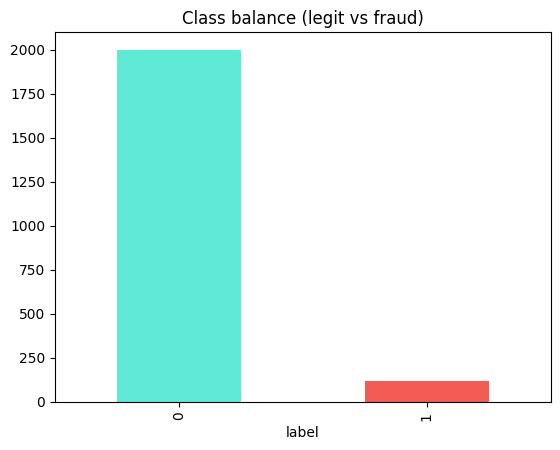

In [3]:
print(df["label"].value_counts())
df["label"].value_counts().plot(kind="bar", color=["#5EEAD4", "#F25C54"])
plt.title("Class balance (legit vs fraud)")
plt.show()


## 2. Train / test split and model training

In [4]:
features = ["amount", "hour", "is_international", "is_new_merchant", "tx_count_last_hr"]
X = df[features]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

clf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["legit", "fraud"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))


              precision    recall  f1-score   support

       legit       0.99      1.00      1.00       500
       fraud       1.00      0.87      0.93        30

    accuracy                           0.99       530
   macro avg       1.00      0.93      0.96       530
weighted avg       0.99      0.99      0.99       530

ROC-AUC: 0.9991


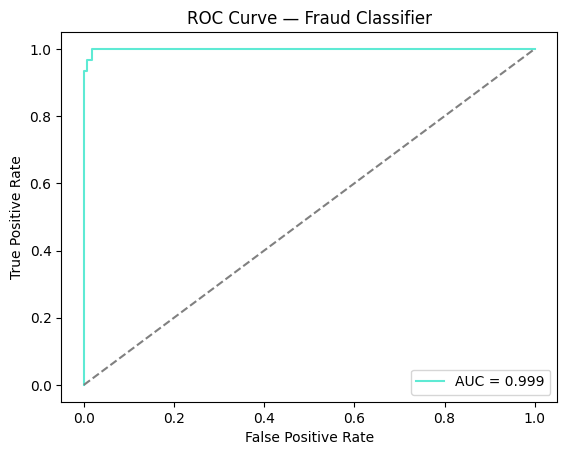

In [5]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, color="#5EEAD4", label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Fraud Classifier")
plt.legend()
plt.show()


## 3. Feature importance

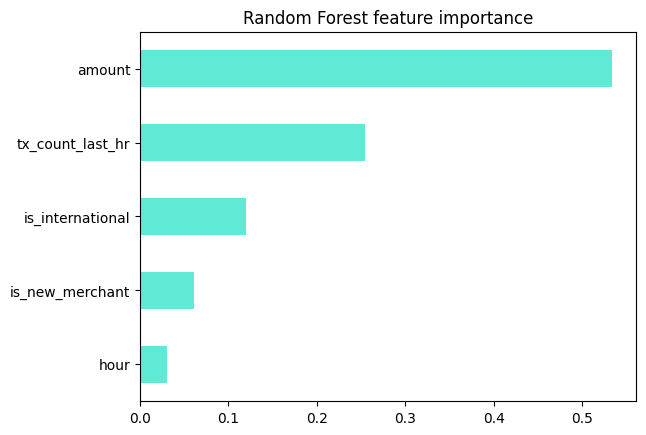

In [6]:
importances = pd.Series(clf.feature_importances_, index=features).sort_values()
importances.plot(kind="barh", color="#5EEAD4")
plt.title("Random Forest feature importance")
plt.show()


## 4. Transparent rule-based scorer (matches the live web demo)

The browser version uses an interpretable, auditable scoring function rather than a black-box model — useful when an analyst needs to explain *why* a transaction was flagged.

In [7]:
def score_transaction(amount, hour, is_international, is_new_merchant, tx_count_last_hr,
                       avg_amount=2400, std_amount=1800):
    risk = 0
    reasons = []
    z = (amount - avg_amount) / std_amount if std_amount else 0
    if z > 3:
        risk += 30; reasons.append(f"Amount {z:.1f}sigma above average")
    elif z > 1.5:
        risk += 15; reasons.append(f"Amount {z:.1f}sigma above average")
    if hour < 6 or hour > 23:
        risk += 15; reasons.append("Off-hours activity")
    if is_international:
        risk += 15; reasons.append("Cross-border transaction")
    if is_new_merchant:
        risk += 10; reasons.append("Unfamiliar merchant")
    if tx_count_last_hr >= 5:
        risk += 25; reasons.append("High velocity")
    elif tx_count_last_hr >= 3:
        risk += 10; reasons.append("Elevated velocity")
    risk = min(100, risk)
    verdict = "block" if risk >= 60 else "review" if risk >= 30 else "approve"
    return risk, verdict, reasons

risk, verdict, reasons = score_transaction(amount=42000, hour=2, is_international=True, is_new_merchant=True, tx_count_last_hr=6)
print(f"Risk score: {risk}/100 -> {verdict.upper()}")
for r in reasons:
    print(" -", r)


Risk score: 95/100 -> BLOCK
 - Amount 22.0sigma above average
 - Off-hours activity
 - Cross-border transaction
 - Unfamiliar merchant
 - High velocity


## Notes

- The Random Forest model learns fraud patterns statistically from labeled examples,
  while the rule-based scorer encodes domain expertise directly — production systems
  often **combine both**: a rules layer for explainability/compliance and an ML layer
  to catch subtler statistical patterns the rules miss.
- The real Kaggle Credit Card Fraud Dataset (284,807 transactions, 492 fraud) is
  heavily imbalanced (~0.17% fraud) — techniques like SMOTE oversampling or
  class-weighting (used here) are essential.
